# Individuell inlämningsuppgift – Deep Learning
## Klassificering av ansiktsuttryck med CNN

I den här notebooken bygger jag neurala nätverk som klassificerar ansiktsuttryck från gråskalebilder. Datasetet består av 48x48-bilder och är uppdelat i `train` och `test`, där varje klass ligger i en egen mapp.

Notebooken fungerar både som kod och rapport. Jag undersöker datan, förbereder bilderna, tränar flera CNN-modeller, jämför resultaten, gör prediktioner på ny data och skriver en kort analys.

Jag har valt modeller som ligger nära kursmaterialet: `Sequential`, `Conv2D`, `MaxPooling2D`, `Dropout`, `BatchNormalization`, callbacks och träningskurvor. Den sista modellen är lite starkare eftersom FER-2013 är svårare än enklare bilddataset.



## 1. Importera bibliotek

Här importeras de bibliotek som används i notebooken. TensorFlow/Keras används för att bygga modellerna och scikit-learn används för metrics som confusion matrix och classification report.


In [ ]:
# Grundläggande bibliotek
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Utvärdering
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Gör resultaten mer jämförbara mellan körningar
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 2. Sökvägar till datasetet

Datan ska ligga i samma mapp som notebooken, i mapparna `train` och `test`.

Exempel:

```text
projektmapp/
├── notebook och requirements
├── sparade modeller
├── train/   → träningsbilder uppdelade i klassmappar
└── test/    → testbilder uppdelade i samma klassmappar
```

Den här notebooken letar inte efter datan i andra mappar. Det är medvetet, eftersom inlämningen ska vara enkel att köra när `train/` och `test/` ligger bredvid notebooken.

Om du kör notebooken i VS Code eller Jupyter och får fel på sökvägarna, kontrollera att arbetsmappen är samma mapp som notebooken ligger i.


In [19]:
# Datasetets mappar ska ligga direkt bredvid notebooken.
# Det gör sökvägarna enkla och tydliga i inlämningen.
DATA_DIR = Path(".")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

# Kontrollera att mapparna finns innan resten av notebooken körs.
# Om detta ger fel: lägg mapparna train/ och test/ i samma mapp som notebooken.
if not TRAIN_DIR.exists():
    raise FileNotFoundError("Hittar inte mappen train/. Den ska ligga i samma mapp som notebooken.")

if not TEST_DIR.exists():
    raise FileNotFoundError("Hittar inte mappen test/. Den ska ligga i samma mapp som notebooken.")

print("Train-mapp:", TRAIN_DIR.resolve())
print("Test-mapp:", TEST_DIR.resolve())


Train-mapp: C:\Users\timry\Documents\DeepLearning\Invidiuell Inlämning\Inviduell_Uppgift\train
Test-mapp: C:\Users\timry\Documents\DeepLearning\Invidiuell Inlämning\Inviduell_Uppgift\test


## 3. Förstå datan

Innan modellen byggs så kontrolleras vilka klasser som finns och hur många bilder varje klass har. 


In [20]:
def count_images_by_class(directory):
    """Räknar jpg/png/jpeg-bilder i varje klassmapp."""
    rows = []
    for class_dir in sorted(directory.iterdir()):
        if class_dir.is_dir():
            image_files = []
            for pattern in ["*.jpg", "*.jpeg", "*.png"]:
                image_files.extend(class_dir.glob(pattern))
            rows.append({"class_name": class_dir.name, "count": len(image_files)})
    return pd.DataFrame(rows)

train_counts = count_images_by_class(TRAIN_DIR)
test_counts = count_images_by_class(TEST_DIR)

class_distribution = train_counts.merge(
    test_counts,
    on="class_name",
    suffixes=("_train", "_test")
)
class_distribution["total"] = class_distribution["count_train"] + class_distribution["count_test"]
class_distribution


,class_name,count_train,count_test,total
0,angry,3995,958,4953
1,disgust,436,111,547
2,fear,4097,1024,5121
3,happy,7215,1774,8989
4,neutral,4965,1233,6198
5,sad,4830,1247,6077
6,surprise,3171,831,4002


Antal träningsbilder: 28709
Antal testbilder: 7178
Antal klasser: 7


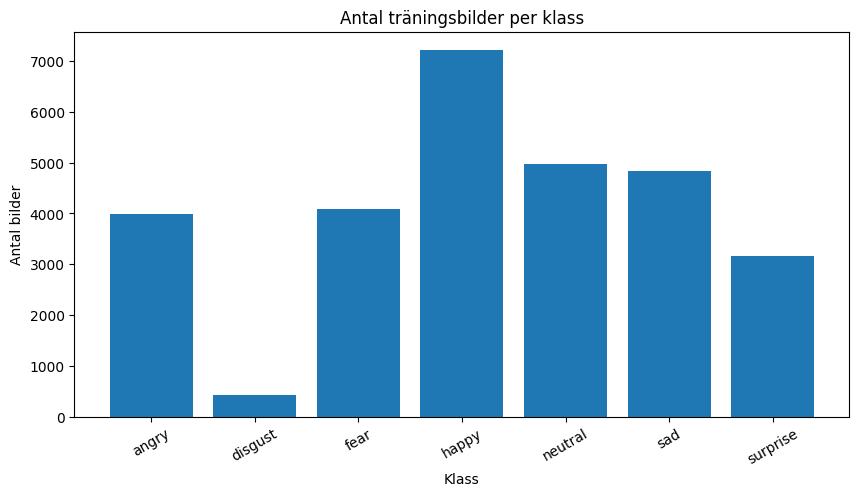

In [21]:
print("Antal träningsbilder:", class_distribution["count_train"].sum())
print("Antal testbilder:", class_distribution["count_test"].sum())
print("Antal klasser:", len(class_distribution))

plt.figure(figsize=(10, 5))
plt.bar(class_distribution["class_name"], class_distribution["count_train"])
plt.title("Antal träningsbilder per klass")
plt.xlabel("Klass")
plt.ylabel("Antal bilder")
plt.xticks(rotation=30)
plt.show()


### Kort analys av datan

>Datasetet innehåller totalt **28 709 träningsbilder** och **7 178 testbilder** fördelade på **7 klasser**: **angry**, **disgust**, **fear**, **happy**, **neutral**, **sad** och **surprise**.

>Fördelningen mellan klasserna är inte helt jämn. Klassen **happy** har tydligt flest träningsbilder, medan **disgust** har klart minst antal bilder. Det betyder att datasetet är obalanserat.

>Detta kan påverka modellen eftersom den får se fler exempel av de vanligaste klasserna under träningen. Modellen kan därför bli bättre på att känna igen klasser med många bilder, till exempel **happy**, och sämre på klasser med få bilder, till exempel **disgust**. För att minska denna påverkan använder jag senare `class_weight`, så att ovanliga klasser får större betydelse när modellen tränas.


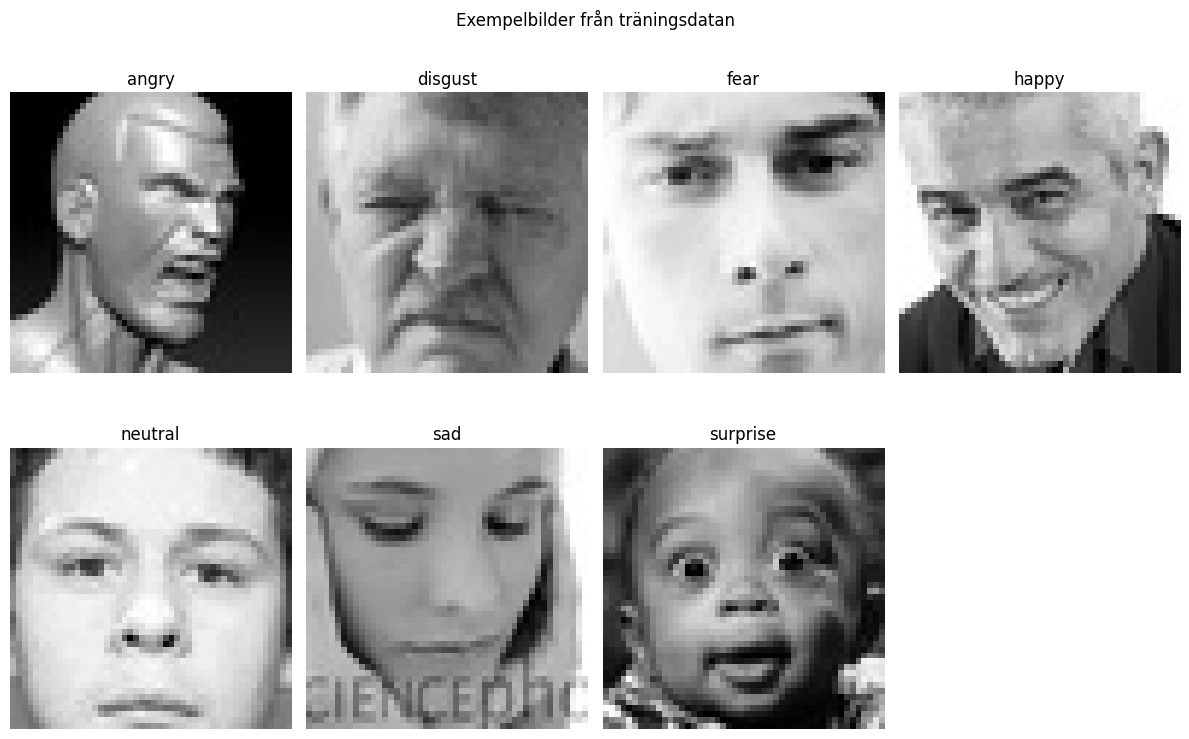

In [22]:
# Visar en exempelbild från varje klass
class_names_from_folders = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])

plt.figure(figsize=(12, 8))
plot_index = 1

for class_name in class_names_from_folders:
    image_paths = list((TRAIN_DIR / class_name).glob("*.jpg"))
    if len(image_paths) == 0:
        image_paths = list((TRAIN_DIR / class_name).glob("*.png"))
    if len(image_paths) == 0:
        continue

    sample_path = random.choice(image_paths)
    img = keras.utils.load_img(sample_path, color_mode="grayscale", target_size=(48, 48))

    plt.subplot(2, 4, plot_index)
    plt.imshow(img, cmap="gray")
    plt.title(class_name)
    plt.axis("off")
    plot_index += 1

plt.suptitle("Exempelbilder från träningsdatan")
plt.tight_layout()
plt.show()


## 4. Förberedelser av data

Bilderna läses in med `image_dataset_from_directory`. Det passar bra här eftersom datasetet redan är sorterat i mappar per klass.

Jag delar träningsmappen i träning och validering. Testmappen används först i slutet för att se hur modellen fungerar på data som den inte har tränats på.

I början kan `USE_SMALL_DATASET = True` användas för att kontrollera att koden fungerar snabbare. När allt fungerar bör den sättas till `False` för seriösare träning.


In [23]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 64
VALIDATION_SPLIT = 0.20

# True = snabb testkörning med färre batchar.
# False = använd hela tränings- och valideringsdatan.
USE_SMALL_DATASET = False
TRAIN_BATCH_LIMIT = 80
VAL_BATCH_LIMIT = 20
TEST_BATCH_LIMIT = None

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int"
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Klasser:", class_names)
print("Antal klasser:", num_classes)


Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.
Klasser: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Antal klasser: 7


In [ ]:
# Begränsa datasetet vid testkörning.
# När USE_SMALL_DATASET är False används hela datasetet.
if USE_SMALL_DATASET:
    train_used = train_ds.take(TRAIN_BATCH_LIMIT)
    val_used = val_ds.take(VAL_BATCH_LIMIT)
    test_used = test_ds.take(TEST_BATCH_LIMIT) if TEST_BATCH_LIMIT else test_ds
else:
    train_used = train_ds
    val_used = val_ds
    test_used = test_ds

# Prefetch gör att nästa batch kan laddas medan modellen tränar på nuvarande batch.
# Det kan göra träningen lite snabbare.
AUTOTUNE = tf.data.AUTOTUNE
train_used = train_used.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_used = val_used.cache().prefetch(AUTOTUNE)
test_used = test_used.cache().prefetch(AUTOTUNE)


In [25]:
# Class weights räknas från träningsmappen.
# Detta kan hjälpa när en klass har mycket färre bilder än de andra.
y_for_weights = []
for idx, class_name in enumerate(class_names):
    n_images = len(list((TRAIN_DIR / class_name).glob("*.jpg")))
    n_images += len(list((TRAIN_DIR / class_name).glob("*.png")))
    n_images += len(list((TRAIN_DIR / class_name).glob("*.jpeg")))
    y_for_weights.extend([idx] * n_images)

y_for_weights = np.array(y_for_weights)
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_for_weights
)
class_weight = {i: float(w) for i, w in enumerate(weights)}
class_weight


{0: 1.0266046844269623,
 1: 9.406618610747051,
 2: 1.0010460615781582,
 3: 0.5684387684387684,
 4: 0.8260394187886635,
 5: 0.8491274770777877,
 6: 1.293372978330405}

### Normalisering och augmentation

>Pixelvärdena ligger från början mellan 0 och 255. I modellerna använder jag `Rescaling(1./255)` för att skala pixelvärdena till ungefär 0-1.

>För de starkare modellerna används även data augmentation. Det betyder att modellen ibland får se lätt förändrade bilder, till exempel lite zoomade eller roterade bilder. Det kan minska overfitting eftersom modellen inte bara lär sig exakt hur träningsbilderna ser ut.

>Eftersom datasetet är obalanserat räknas class weights ut från träningsmappen. Koden räknar hur många bilder som finns i varje klass och använder sedan `compute_class_weight` för att ge högre vikt till klasser med få bilder. Det gör att modellen inte bara fokuserar på de vanligaste klasserna, utan även tar mer hänsyn till mindre klasser som till exempel `disgust`.


## 5. Hjälpfunktioner för träning och utvärdering

För att kunna jämföra modellerna rättvist använder jag samma hjälpfunktioner för träning, grafer och testutvärdering.


In [26]:
def plot_history(history, title="Träningskurvor"):
    """Plottar loss och accuracy för training och validation."""
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(7, 5))
    plt.plot(history_df["loss"], label="train_loss")
    plt.plot(history_df["val_loss"], label="val_loss")
    plt.title(title + " - loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(history_df["accuracy"], label="train_accuracy")
    plt.plot(history_df["val_accuracy"], label="val_accuracy")
    plt.title(title + " - accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


def make_callbacks(model_name):
    """Callbacks som används för modellerna.
    EarlyStopping stoppar träningen när valideringen inte förbättras.
    ReduceLROnPlateau sänker learning rate om modellen fastnar.
    ModelCheckpoint sparar bästa modellen enligt val_accuracy.
    """
    Path("models").mkdir(exist_ok=True)

    return [
        keras.callbacks.ModelCheckpoint(
            filepath=f"models/{model_name}.keras",
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ]


def train_and_evaluate(model, model_name, epochs=25, use_class_weight=True):
    """Tränar en modell och utvärderar den på testdata."""
    print("\n" + "="*70)
    print("Tränar modell:", model_name)
    print("="*70)

    start_time = time.time()

    history = model.fit(
        train_used,
        validation_data=val_used,
        epochs=epochs,
        callbacks=make_callbacks(model_name),
        class_weight=class_weight if use_class_weight else None
    )

    training_time = time.time() - start_time
    test_loss, test_accuracy = model.evaluate(test_used, verbose=0)

    print(f"Test loss: {test_loss:.4f}")
    print(f"Test accuracy: {test_accuracy:.4f}")
    print(f"Träningstid: {training_time/60:.1f} minuter")

    result = {
        "model_name": model_name,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "best_val_accuracy": max(history.history["val_accuracy"]),
        "final_train_accuracy": history.history["accuracy"][-1],
        "final_val_accuracy": history.history["val_accuracy"][-1],
        "training_time_minutes": training_time / 60
    }

    return history, result


def get_predictions(model, dataset):
    """Hämtar true labels och prediktioner från ett dataset."""
    y_true = []
    y_pred = []

    for images, labels in dataset:
        probabilities = model.predict(images, verbose=0)
        predictions = np.argmax(probabilities, axis=1)
        y_true.extend(labels.numpy())
        y_pred.extend(predictions)

    return np.array(y_true), np.array(y_pred)


### Kommentar:
>Jag använder tre callbacks under träningen. `ModelCheckpoint` sparar den bästa modellen enligt validation accuracy. `EarlyStopping` stoppar träningen om validation loss inte förbättras efter flera epochs, vilket minskar risken för onödig träning och overfitting. `ReduceLROnPlateau` sänker learning rate om validation loss fastnar, så att modellen kan fortsätta träna med mindre steg.

## 6. Modell 1 – enkel baseline CNN

Den första modellen är medvetet enkel. Syftet är att få en startpunkt att jämföra mot. Beroende på hur den presterar så kan jag utvärdera hur de andra modellerna ställer sig till den. Om förändringar gör det bättre eller sämre.


In [27]:
def build_baseline_cnn():
    model = keras.Sequential([
        layers.Input(shape=(48, 48, 1)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,495 (4.58 MB)

 Trainable params: 1,199,495 (4.58 MB)

 Non-trainable params: 0 (0.00 B)


Tränar modell: 01_baseline_cnn
Epoch 1/20
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1527 - loss: 1.9694
Epoch 1: val_accuracy improved from None to 0.30779, saving model to models/01_baseline_cnn.keras

Epoch 1: finished saving model to models/01_baseline_cnn.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.1955 - loss: 1.9103 - val_accuracy: 0.3078 - val_loss: 1.7708 - learning_rate: 0.0010
Epoch 2/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3028 - loss: 1.7600
Epoch 2: val_accuracy did not improve from 0.30779
359/359 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.3128 - loss: 1.7473 - val_accuracy: 0.2797 - val_loss: 1.7721 - learning_rate: 0.0010
Epoch 3/20
357/359 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3539 - loss: 1.6520
Epoch 3: val_accuracy improved from 0.30779 to 0.39349, saving model to models/01_baseline_cnn.keras

Epoch 3: finished saving model to models/01_baseline_cnn.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - 

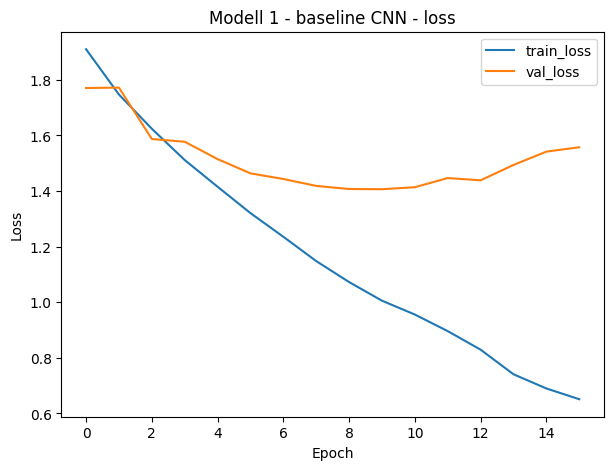

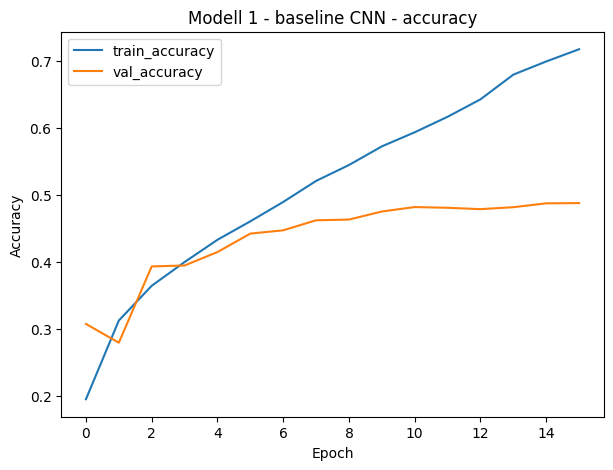

In [ ]:
history_baseline, result_baseline = train_and_evaluate(
    baseline_model,
    model_name="01_baseline_cnn",
    epochs=20,
    use_class_weight=True
)
plot_history(history_baseline, "Modell 1 - baseline CNN")


In [42]:
best_val_accuracy = max(history_baseline.history["val_accuracy"])

print("Bästa validation accuracy:", best_val_accuracy)
print("Bästa validation accuracy i procent:", best_val_accuracy * 100)

Bästa validation accuracy: 0.48789408802986145
Bästa validation accuracy i procent: 48.789408802986145


### Analys av modell 1

- Test accuracy: `0.47`
- Test loss: `1.39`
- Bästa validation accuracy: `48.79%`

Kort tolkning:

>Modell 1 användes som en enkel baseline-CNN. Modellen fick en test accuracy på 47,28 % och en bästa validation accuracy på 48,79 %. Resultatet är bättre än slumpmässig gissning, eftersom datasetet har sju klasser, men det visar också att modellen har svårt att skilja mellan flera ansiktsuttryck.

>En tydlig sak i resultatet är skillnaden mellan final train accuracy och validation accuracy. Train accuracy blev 71,73 %, medan final validation accuracy bara blev 48,79 %. Det betyder att modellen lärde sig träningsdatan betydligt bättre än den generaliserade till ny data.

>Loss-kurvan visar också tecken på overfitting. Train loss fortsätter att sjunka under träningen, medan validation loss planar ut och börjar öka efter ett antal epochs. Det innebär att modellen fortsätter att förbättras på träningsdatan, men inte på validationdata.

>Modellen fungerar därför bra som baseline. Den visar att en enkel CNN kan lära sig vissa mönster från bilderna, men modellen är för enkel och/eller för dåligt regulariserad för att ge ett starkt resultat på ny data.


## 7. Modell 2 – CNN med augmentation, batch normalization och dropout

Den andra modellen är fortfarande en egen CNN, men den är mer anpassad för bilddata. Den använder:

- Data augmentation för att minska overfitting
- Flera convolution-block
- Batch normalization för stabilare träning
- Dropout för att modellen inte ska memorera träningsdatan för mycket
- Global average pooling istället för ett stort flatten-lager, vilket ger färre parametrar

Den här modellen är min huvudmodell eftersom den ligger nära kursmaterialet men är starkare än en enkel baseline.


In [29]:
def build_regularized_cnn():
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.08),
        layers.RandomTranslation(0.05, 0.05),
    ], name="data_augmentation")

    model = keras.Sequential([
        layers.Input(shape=(48, 48, 1)),
        layers.Rescaling(1./255),
        data_augmentation,

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.20),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.30),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.45),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

regularized_model = build_regularized_cnn()
regularized_model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 306,151 (1.17 MB)

 Trainable params: 304,999 (1.16 MB)

 Non-trainable params: 1,152 (4.50 KB)


Tränar modell: 02_regularized_cnn
Epoch 1/35
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.1531 - loss: 2.4173
Epoch 1: val_accuracy improved from None to 0.17018, saving model to models/02_regularized_cnn.keras

Epoch 1: finished saving model to models/02_regularized_cnn.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 44s 117ms/step - accuracy: 0.1580 - loss: 2.3047 - val_accuracy: 0.1702 - val_loss: 1.9721 - learning_rate: 0.0010
Epoch 2/35
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.1796 - loss: 2.0797
Epoch 2: val_accuracy did not improve from 0.17018
359/359 ━━━━━━━━━━━━━━━━━━━━ 42s 116ms/step - accuracy: 0.1799 - loss: 2.0422 - val_accuracy: 0.0512 - val_loss: 2.4244 - learning_rate: 0.0010
Epoch 3/35
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.2171 - loss: 1.9156
Epoch 3: val_accuracy improved from 0.17018 to 0.25187, saving model to models/02_regularized_cnn.keras

Epoch 3: finished saving model to models/02_regularized_cnn.keras
359/359 ━━━━━━━━━━━━━━━

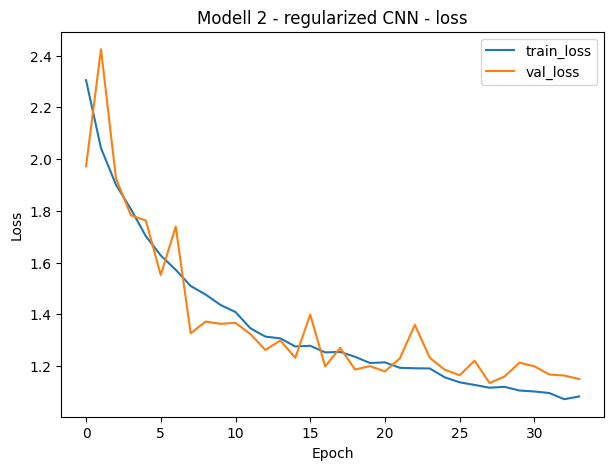

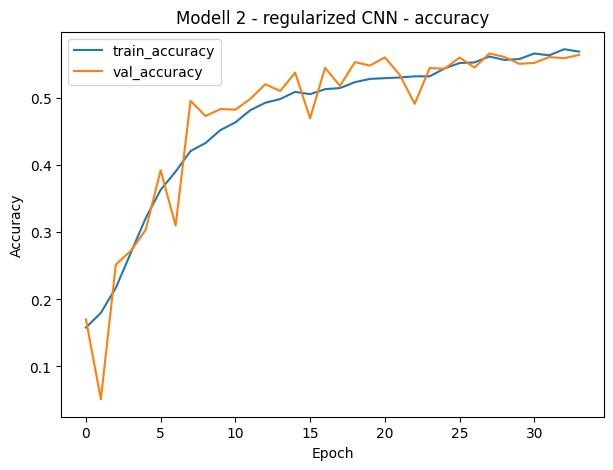

In [30]:
history_regularized, result_regularized = train_and_evaluate(
    regularized_model,
    model_name="02_regularized_cnn",
    epochs=35,
    use_class_weight=True
)
plot_history(history_regularized, "Modell 2 - regularized CNN")


In [43]:
best_val_accuracy_regularized = max(history_regularized.history["val_accuracy"])

print("Bästa validation accuracy:", best_val_accuracy_regularized)
print("Bästa validation accuracy i procent:", best_val_accuracy_regularized * 100)

Bästa validation accuracy: 0.5666260123252869
Bästa validation accuracy i procent: 56.66260123252869


### Analys av modell 2

- Test accuracy: `0.57`
- Test loss: `1.12`
- Bästa validation accuracy: `56.66%`

Kort tolkning:

>Modell 2 presterade tydligt bättre än modell 1. Test accuracy ökade från 47,28 % till 56,80 %, vilket är en förbättring på ungefär 9,5 procentenheter. Test loss minskade också från 1.393660 till 1.122438. Det innebär att modell 2 både klassificerade fler bilder rätt och gjorde mindre fel i sina prediktioner.

>Den största skillnaden är att modell 2 generaliserade bättre. I modell 1 blev final train accuracy 71,73 %, medan final validation accuracy bara blev 48,79 %. Det visar tydlig overfitting. I modell 2 låg final train accuracy på 56,94 % och final validation accuracy på 56,45 %, vilket är mycket närmare varandra.

>Det tyder på att regulariseringen i modell 2 hjälpte. Dropout, batch normalization och data augmentation gör att modellen inte lika lätt memorerar träningsbilderna, utan lär sig mer generella mönster. Därför blev validation- och testresultatet bättre.

>Nackdelen är att träningstiden ökade från 2,07 minuter till 34,05 minuter. Modell 2 är alltså tydligt bättre än modell 1, men den kräver också mer träningstid.


## 8. Modell 3 – djupare CNN för bättre representationer

Den tredje modellen testar om fler convolution-block kan ge bättre resultat. Idén är att tidiga lager lär sig enklare mönster som kanter och kontraster, medan djupare lager kan lära sig mer sammansatta ansiktsdrag.

Jag gör inte modellen extremt stor, eftersom bilderna bara är 48x48 pixlar och en för stor modell lätt kan överanpassa.


In [31]:
def build_deeper_cnn():
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.06),
        layers.RandomZoom(0.06),
        layers.RandomContrast(0.10),
    ], name="data_augmentation")

    model = keras.Sequential([
        layers.Input(shape=(48, 48, 1)),
        layers.Rescaling(1./255),
        data_augmentation,

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.15),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.20),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.30),

        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.35),

        layers.GlobalAveragePooling2D(),
        layers.Dense(192, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.50),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

deeper_model = build_deeper_cnn()
deeper_model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 6, 6, 256)      │         1,02

 Total params: 635,879 (2.43 MB)

 Trainable params: 634,087 (2.42 MB)

 Non-trainable params: 1,792 (7.00 KB)


Tränar modell: 03_deeper_cnn
Epoch 1/45


359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.1547 - loss: 2.6464
Epoch 1: val_accuracy improved from None to 0.18080, saving model to models/03_deeper_cnn.keras

Epoch 1: finished saving model to models/03_deeper_cnn.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 48s 126ms/step - accuracy: 0.1590 - loss: 2.4008 - val_accuracy: 0.1808 - val_loss: 2.0094 - learning_rate: 0.0010
Epoch 2/45
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.1686 - loss: 2.1587
Epoch 2: val_accuracy improved from 0.18080 to 0.19491, saving model to models/03_deeper_cnn.keras

Epoch 2: finished saving model to models/03_deeper_cnn.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 44s 123ms/step - accuracy: 0.1736 - loss: 2.0893 - val_accuracy: 0.1949 - val_loss: 1.9946 - learning_rate: 0.0010
Epoch 3/45
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.1989 - loss: 1.9654
Epoch 3: val_accuracy did not improve from 0.19491
359/359 ━━━━━━━━━━━━━━━━━━━━ 44s 123ms/step - accuracy: 0.2110 - loss: 1.9177 - val_accur

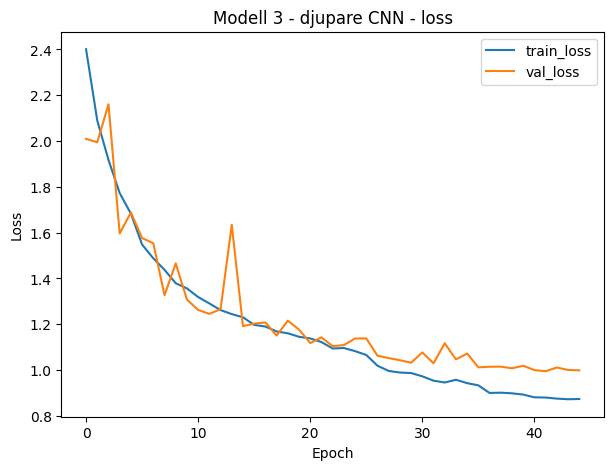

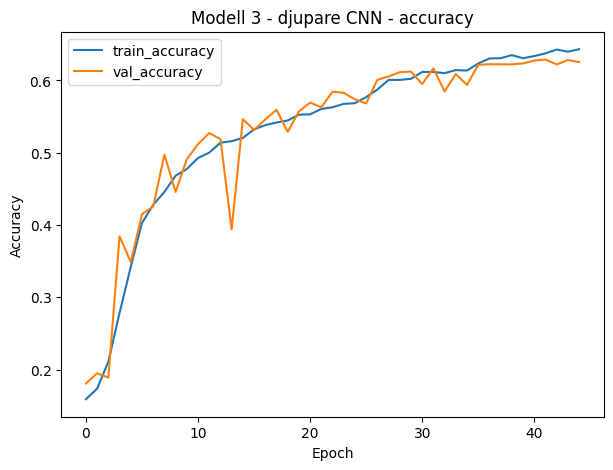

In [32]:
history_deeper, result_deeper = train_and_evaluate(
    deeper_model,
    model_name="03_deeper_cnn",
    epochs=45,
    use_class_weight=True
)
plot_history(history_deeper, "Modell 3 - djupare CNN")


### Analys av modell 3

- Test accuracy: `0.63`
- Test loss: `0.98`
- Bästa validation accuracy: `62.89%`

Kort tolkning:

>Modell 3 är den djupaste modellen och gav det bästa resultatet av de tre modellerna. Den fick en test accuracy på 63,10 % och en test loss på 0.980763. Det är både högre accuracy och lägre loss än modell 1 och modell 2.

>Loss-kurvan visar att både train loss och validation loss sjunker tydligt under träningen. I början är kurvorna lite ojämna, men efter ungefär 15–20 epochs blir utvecklingen mer stabil. Train loss fortsätter att minska ner till cirka 0.9, medan validation loss hamnar runt cirka 1.0 mot slutet. Skillnaden mellan train loss och validation loss är relativt liten, vilket tyder på att modellen inte överanpassar lika kraftigt som baseline-modellen.

>Accuracy-kurvan visar också en stabil förbättring. Både train accuracy och validation accuracy ökar under träningen och ligger nära varandra under större delen av träningen. Mot slutet når modellen en final train accuracy på 64,32 % och en final validation accuracy på 62,55 %. Eftersom skillnaden mellan dessa värden är liten verkar modellen generalisera ganska bra till ny data.

>Det finns fortfarande en viss skillnad mellan train och validation, så modellen är inte helt fri från overfitting. Däremot är överanpassningen betydligt mindre än i modell 1. Det viktigaste är att validation accuracy fortsätter ligga nära train accuracy samtidigt som testresultatet också är starkt.

>Jämfört med modell 2 förbättrades test accuracy från 56,80 % till 63,10 %. Test loss minskade också från 1.122438 till 0.980763. Detta tyder på att den djupare CNN-strukturen kunde lära sig mer avancerade mönster i bilderna, till exempel former runt ögon, mun och ansiktsdrag som kan skilja olika uttryck åt.

>Nackdelen med modell 3 är träningstiden. Den tog 198,98 minuter att träna, vilket är mycket längre än modell 2 som tog 34,05 minuter och modell 1 som tog 2,07 minuter. Modell 3 är därför bäst resultatmässigt, men den är också mest krävande att träna.


## 9. Jämförelse av modellerna

Här samlar jag resultaten i en tabell. Det gör det lättare att se vilken modell som fungerade bäst och om en mer avancerad modell faktiskt gav bättre resultat.


In [47]:
results = [result_baseline, result_regularized, result_deeper]

results_df = pd.DataFrame(results).sort_values("test_accuracy", ascending=False)
results_df


,model_name,test_loss,test_accuracy,best_val_accuracy,final_train_accuracy,final_val_accuracy,training_time_minutes
2,03_deeper_cnn,0.980763,0.630956,0.628985,0.643243,0.625501,198.975008
1,02_regularized_cnn,1.122438,0.567986,0.566626,0.569357,0.564536,34.053852
0,01_baseline_cnn,1.393662,0.472834,0.487894,0.717302,0.487894,2.070971


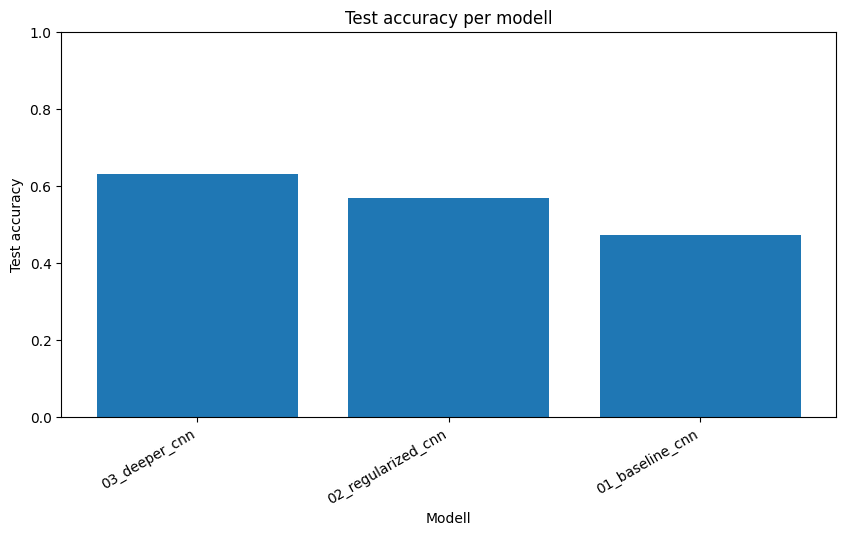

In [36]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["model_name"], results_df["test_accuracy"])
plt.title("Test accuracy per modell")
plt.xlabel("Modell")
plt.ylabel("Test accuracy")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.show()


### Sammanfattning av modelljämförelse

| Modell | Test accuracy | Test loss | Kommentar |
|---|---:|---:|---|
| Baseline CNN | 47,28 % | 1.393660 | Enkel modell som fungerar som baseline, men visar tydliga tecken på overfitting. Train accuracy blev mycket högre än validation accuracy. |
| Regularized CNN | 56,80 % | 1.122438 | Presterade tydligt bättre än baseline. Regularisering och data augmentation verkar ha minskat overfitting och förbättrat generaliseringen. |
| Djupare CNN | 63,10 % | 0.980763 | Bästa modellen. Högst test accuracy och lägst test loss. Kurvorna visar relativt liten skillnad mellan train och validation, men träningstiden var mycket längre. |
    

---------    

>Den bästa modellen blev **Djupare CNN** med en test accuracy på **63,10 %** och test loss på **0.980763**. Den presterade bättre än både baseline-modellen och den regulariserade modellen.

>Jämfört med baseline-modellen ökade test accuracy från **47,28 %** till **63,10 %**. Det är en förbättring på ungefär **15,8 procentenheter**. Baseline-modellen hade också tydliga tecken på overfitting, eftersom final train accuracy var **71,73 %** medan final validation accuracy bara var **48,79 %**.

>Modell 2 förbättrade resultatet jämfört med baseline och fick **56,80 %** test accuracy. Skillnaden mellan final train accuracy och final validation accuracy var liten, **56,94 %** jämfört med **56,45 %**, vilket tyder på att regularisering, dropout och data augmentation hjälpte modellen att generalisera bättre.

>Modell 3 förbättrade resultatet ytterligare. Den fick **64,32 %** final train accuracy och **62,55 %** final validation accuracy. Skillnaden mellan dessa värden är relativt liten, vilket betyder att modellen bara visar svaga tecken på overfitting. Den djupare strukturen verkar ha hjälpt modellen att lära sig mer avancerade mönster i bilderna.

>Samtidigt tog modell 3 längst tid att träna, cirka **199 minuter**, jämfört med cirka **34 minuter** för modell 2 och cirka **2 minuter** för modell 1. Därför är modell 3 bäst om målet är högst accuracy, medan modell 2 kan vara ett mer praktiskt alternativ om träningstid är viktigt.


## 10. Utvärdera bästa modellen mer detaljerat

Här väljer jag den modell som fick högst test accuracy och tittar på confusion matrix och classification report. Det gör det lättare att se vilka klasser modellen blandar ihop.


Bästa modell enligt test accuracy: 03_deeper_cnn
Laddar modell från: models\03_deeper_cnn.keras
              precision    recall  f1-score   support

       angry       0.55      0.60      0.57       958
     disgust       0.48      0.67      0.56       111
        fear       0.45      0.35      0.40      1024
       happy       0.87      0.84      0.85      1774
     neutral       0.57      0.63      0.60      1233
         sad       0.52      0.46      0.49      1247
    surprise       0.69      0.81      0.74       831

    accuracy                           0.63      7178
   macro avg       0.59      0.62      0.60      7178
weighted avg       0.63      0.63      0.63      7178



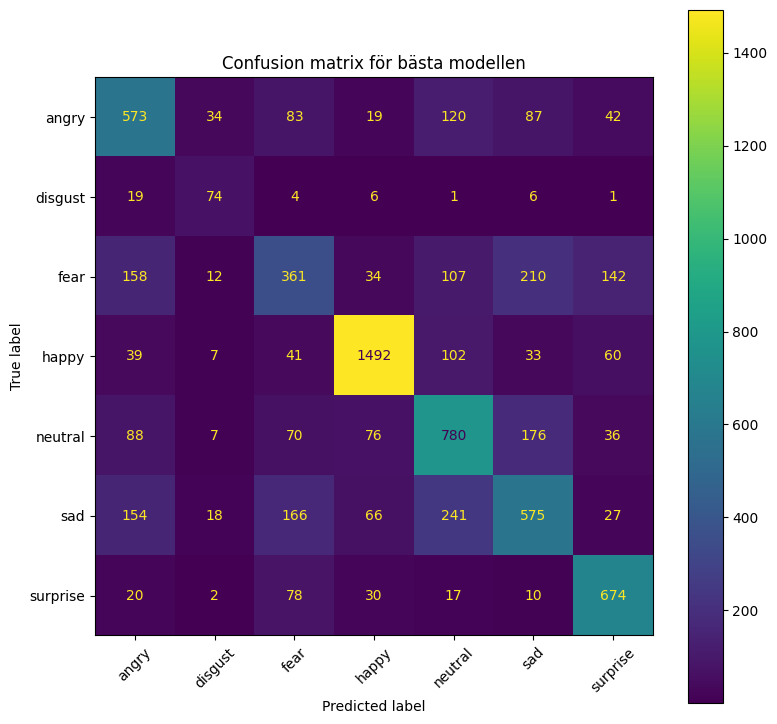

In [37]:
best_model_name = results_df.iloc[0]["model_name"]
best_model_path = Path("models") / f"{best_model_name}.keras"

print("Bästa modell enligt test accuracy:", best_model_name)
print("Laddar modell från:", best_model_path)

best_model = keras.models.load_model(best_model_path)

y_true, y_pred = get_predictions(best_model, test_used)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, xticks_rotation=45, cmap=None)
plt.title("Confusion matrix för bästa modellen")
plt.show()


### Analys av confusion matrix

>Confusion matrix visar att den bästa modellen, **03_deeper_cnn**, oftast klassificerar **happy** korrekt. Av 1774 happy-bilder klassificerades 1492 rätt, vilket också syns i classification report där happy fick högst precision, recall och f1-score. Modellen verkar även fungera relativt bra för **surprise**, där 674 av 831 bilder klassificerades rätt.

>Modellen har svårare för klasser som **fear** och **sad**. För fear blev bara 361 av 1024 bilder rätt klassificerade. Många fear-bilder blandades ihop med angry, sad, surprise och neutral. Detta kan bero på att fear ofta kan likna andra starka ansiktsuttryck, särskilt surprise eller angry, beroende på hur ansiktet ser ut på bilden.

>För sad blev 575 av 1247 bilder rätt. Sad blandades framför allt ihop med neutral, fear och angry. Det är rimligt eftersom sad och neutral ofta kan vara ganska lika i gråskalebilder, särskilt om ansiktsuttrycket är svagt eller bilden är otydlig.

>Klassen **disgust** har ganska hög recall på 0.67, men support är mycket lägre än för de andra klasserna, bara 111 testbilder. Det betyder att resultatet för disgust bör tolkas försiktigt. Eftersom klassen är liten kan några få felklassificeringar påverka värdena mycket.

>Sammanfattningsvis visar confusion matrix att modellen är bäst på tydliga uttryck som **happy** och **surprise**, men har svårare med uttryck som liknar varandra, till exempel **sad**, **neutral** och **fear**. Detta är en begränsning med datasetet och modellen, eftersom ansiktsuttryck inte alltid är tydliga och vissa klasser överlappar visuellt.


## 11. Gör prediktion på en ny bild

Uppgiften kräver att modellen används för att göra prediktion på ny data. Här väljer jag en bild från testmappen, eftersom testbilderna inte har använts vid träningen.

Man kan även byta `image_path` till en egen bild om man vill testa modellen mer praktiskt.


Testbild: test\angry\PrivateTest_10131363.jpg


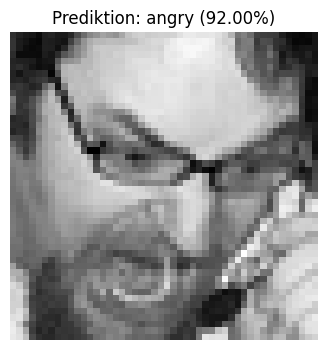

,class_name,probability
0,angry,0.920035
3,happy,0.034975
2,fear,0.023639
5,sad,0.013800
4,neutral,0.004454
6,surprise,0.001879
1,disgust,0.001218


In [46]:
def predict_single_image(model, image_path):
    """Läser in en bild, förbereder den och låter modellen prediktera klass."""
    img = keras.utils.load_img(
        image_path,
        color_mode="grayscale",
        target_size=IMG_SIZE
    )
    img_array = keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    probabilities = model.predict(img_array, verbose=0)[0]
    predicted_index = np.argmax(probabilities)
    predicted_class = class_names[predicted_index]
    confidence = probabilities[predicted_index]

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(f"Prediktion: {predicted_class} ({confidence:.2%})")
    plt.show()

    prob_df = pd.DataFrame({
        "class_name": class_names,
        "probability": probabilities
    }).sort_values("probability", ascending=False)

    return predicted_class, confidence, prob_df

# Välj en testbild automatiskt
example_class = class_names[0]
example_images = list((TEST_DIR / example_class).glob("*.jpg"))
if len(example_images) == 0:
    example_images = list((TEST_DIR / example_class).glob("*.png"))

image_path = example_images[0]
print("Testbild:", image_path)

predicted_class, confidence, prob_df = predict_single_image(best_model, image_path)
prob_df


### Kommentar till prediktionen

>Jag testade modellen på en bild som modellen bedömde som **angry**. Modellen predikterade **angry** med en sannolikhet på **92,00 %**. De näst högsta sannolikheterna var **happy** med cirka **3,50 %** och **fear** med cirka **2,36 %**, vilket betyder att modellen var ganska säker i sin prediktion.

>Prediktionen verkar rimlig eftersom ansiktet på bilden har ett spänt uttryck, tydliga ögonbryn och en munform som kan kopplas till ilska. Det visar hur modellen kan användas som ett program för att klassificera en ny bild: bilden läses in, förbehandlas på samma sätt som träningsdatan och skickas sedan in i modellen som returnerar sannolikheter för varje klass.

>Samtidigt ska resultatet tolkas försiktigt. En hög sannolikhet betyder inte alltid att modellen har rätt, utan bara att modellen själv är säker på sin klassificering. Eftersom ansiktsuttryck kan vara otydliga och flera klasser kan likna varandra är det viktigt att även titta på bilden visuellt och inte bara på sannolikhetsvärdet.


## 12. Analys av resultatet

### Hur bra fungerar modellen?

>Den bästa modellen blev **03_deeper_cnn**. Den fick en test accuracy på **63,10 %** och en test loss på **0.980763**. Det betyder att modellen klassificerar ungefär **63 %** av testbilderna rätt.
>Resultatet är rimligt och ganska bra med tanke på att FER-2013 är ett svårt dataset. Bilderna är små, i gråskala och bara 48x48 pixlar. Dessutom finns det flera ansiktsuttryck som kan likna varandra, till exempel **sad**, **neutral** och **fear**. Modellen fungerar bäst på tydliga uttryck som **happy** och **surprise**, men har svårare med mer otydliga eller liknande uttryck.

### Ser jag tecken på overfitting eller underfitting?

>Jag ser **svaga tecken på overfitting**, men inte lika tydligt som i baseline-modellen. För den bästa modellen blev final training accuracy **64,32 %**, medan final validation accuracy blev **62,55 %**. Skillnaden är alltså ganska liten.

>Det betyder att modellen presterar lite bättre på träningsdatan än på validationdatan, men skillnaden är inte så stor att modellen verkar ha memorerat träningsdatan. Detta tyder på att modellen generaliserar relativt bra till ny data.

>Dropout, data augmentation, batch normalization och EarlyStopping användes för att minska overfitting. Resultatet visar att dessa metoder troligen hjälpte, särskilt om man jämför med baseline-modellen där skillnaden mellan train och validation var mycket större.

### Hur skiljer sig resultatet mellan träningsdata och testdata?

>För den bästa modellen blev final training accuracy **64,32 %**, final validation accuracy **62,55 %** och test accuracy **63,10 %**.

>Test accuracy ligger alltså väldigt nära validation accuracy. Det är positivt, eftersom testdatan inte användes när modellen tränades. Det tyder på att validation-resultatet gav en ganska bra bild av hur modellen skulle prestera på helt ny data.

>Jämfört med baseline-modellen är skillnaden tydlig. Baseline-modellen fick **71,73 %** final training accuracy men bara **48,79 %** final validation accuracy och **47,28 %** test accuracy. Det visar att baseline-modellen överanpassade mycket mer. Den djupare modellen hade däremot bättre balans mellan train, validation och test.

### Vad verkar påverka resultatet mest?

>De saker som verkar påverka resultatet mest är modellens djup, regularisering, data augmentation och klassobalansen i datasetet.

>När modellen blev djupare ökade test accuracy från **47,28 %** i baseline-modellen till **63,10 %** i den djupare modellen. Det tyder på att fler convolution-lager hjälpte modellen att lära sig mer avancerade mönster i bilderna, till exempel former runt ögon, mun och ansiktsdrag.

>Regularisering verkar också ha haft stor betydelse. Modell 2, som använde mer regularisering och augmentation, fick **56,80 %** test accuracy och hade mycket mindre skillnad mellan training och validation än baseline-modellen. Detta tyder på att dropout, batch normalization och augmentation hjälpte modellen att generalisera bättre.

>Klassobalansen påverkar också resultatet. Vissa klasser, till exempel **happy**, har många fler bilder och blev också lättare för modellen att klassificera. Andra klasser, som **disgust**, har mycket färre exempel, vilket gör resultatet mer osäkert för den klassen.

### Vilka begränsningar har modellen?

>Modellen har flera begränsningar. Bilderna är små, bara **48x48 pixlar**, vilket gör att detaljer i ansiktet kan försvinna. Eftersom bilderna är i gråskala saknas också färginformation som ibland hade kunnat hjälpa.

>Datasetet är dessutom obalanserat. Till exempel finns det betydligt fler bilder av **happy** än av **disgust**. Det gör att modellen får mer träning på vissa uttryck än andra, vilket kan påverka hur bra den lär sig varje klass.

>En annan begränsning är att ansiktsuttryck är subjektiva. En bild kan ibland tolkas som både **neutral**, **sad** eller **fear**, beroende på personen som tittar. Confusion matrix visade också att modellen ofta blandade ihop just sådana klasser.

>Det kan även finnas otydliga, felbeskurna eller lågkvalitativa bilder i datasetet. Om sådana bilder finns i träningsdatan kan modellen få svårare att lära sig tydliga mönster. Om de finns i testdatan kan testresultatet bli lägre.

>Modellen fungerar därför bra som ett experiment i bildklassificering med CNN, men den bör inte användas som ett säkert system för att tolka människors känslor i verkliga situationer.

## 13. Reflektion

### Vad var svårast?

>Det svåraste var att få modellen att prestera bättre på ny data utan att överanpassa på träningsdatan. Baseline-modellen fick relativt hög training accuracy men mycket lägre validation och test accuracy, vilket visade att modellen lärde sig träningsdatan bättre än den generaliserade.

>En annan utmaning var att tolka resultaten och förstå varför vissa klasser blev svårare än andra. Confusion matrix visade till exempel att modellen hade lättare för tydliga uttryck som happy och surprise, men svårare för uttryck som fear, sad och neutral. Det visar att problemet inte bara handlar om att få hög accuracy, utan också om att förstå vilka fel modellen gör.

### Vad lärde jag mig?

>Jag lärde mig hur en CNN kan användas för bildklassificering och hur convolution-lager kan hitta mönster i bilder, till exempel former runt ögon, mun och ansikte. Jag lärde mig också hur bilder behöver förberedas innan träning, bland annat genom skalning/normalisering och att datan delas upp i train, validation och test.

>En viktig sak jag lärde mig var hur träningskurvor kan användas för att upptäcka overfitting. När train loss fortsätter att sjunka men validation loss inte förbättras är det ett tecken på att modellen inte generaliserar lika bra. Jag lärde mig också att tekniker som dropout, batch normalization, data augmentation och EarlyStopping kan hjälpa modellen att prestera bättre på ny data.

### Vad hade jag gjort annorlunda om jag började om?

>Om jag började om hade jag planerat testerna mer stegvis från början. Jag hade först tränat en liten baseline-modell, sedan bara ändrat en eller två saker i taget för att tydligare se vad som faktiskt förbättrade resultatet.

>Jag hade också lagt mer tid på att undersöka datakvaliteten innan träningen. Vissa bilder kan vara otydliga, felbeskurna eller svåra att tolka även för en människa. Det hade därför varit bra att granska fler exempel från varje klass och eventuellt skapa en tydligare strategi för hur sådana bilder ska hanteras.

>Om jag hade haft mer tid hade jag även testat fler kombinationer av dropout, learning rate, batch size och antal epochs. Jag hade också kunnat testa transfer learning mer noggrant och jämföra det med de egna CNN-modellerna.

### Vilket betyg tycker jag att inlämningen motsvarar?

>Jag tycker att inlämningen motsvarar **VG**.

>Den uppfyller kraven för G eftersom den bygger en fungerande CNN-modell, tränar och utvärderar modellen, gör prediktion på ny data och analyserar resultatet. Modellen sparas också så att den kan användas igen.

>Jag tycker även att arbetet motiverar VG eftersom flera modellvarianter testades och jämfördes. Baseline-modellen jämfördes med en regulariserad CNN och en djupare CNN. Resultaten analyserades med test accuracy, test loss, träningskurvor, classification report och confusion matrix.

>Arbetet visar också hur olika val påverkar resultatet. Modell 2 visade att regularisering och data augmentation kunde minska overfitting jämfört med baseline. Modell 3 visade att en djupare CNN kunde ge bättre resultat, men också att träningstiden blev mycket längre. Därför innehåller arbetet både modelljämförelse, förbättringar och en kritisk diskussion om begränsningar.


## 14. Spara slutmodell



In [39]:
best_model.save("best_fer_model.keras")
print("Bästa modellen sparad som best_fer_model.keras")


Bästa modellen sparad som best_fer_model.keras


## 15. Extra kontroll av bilderna

Då jag märkte att det fanns några bilder i datan så valde jag att undersöka hur utbrett det var. Genom att försöka hitta bilder med lite variation eller till och med enfärgade.

Antal misstänkta bilder: 39


,path,dataset,class_name,mean,std,min,max,white_ratio,dark_ratio,reason
0,train\angry\Training_10131352.jpg,train,angry,0.00,0.00,0,0,0.000,1.000,"Låg pixelvariation, Nästan enfärgad bild, Myck..."
1,train\angry\Training_28756096.jpg,train,angry,0.00,0.00,0,0,0.000,1.000,"Låg pixelvariation, Nästan enfärgad bild, Myck..."
2,train\angry\Training_32571770.jpg,train,angry,0.00,0.00,0,0,0.000,1.000,"Låg pixelvariation, Nästan enfärgad bild, Myck..."
3,train\angry\Training_52563817.jpg,train,angry,0.00,0.00,0,0,0.000,1.000,"Låg pixelvariation, Nästan enfärgad bild, Myck..."
4,train\angry\Training_67604214.jpg,train,angry,240.88,23.14,135,255,0.873,0.000,Stor ljus yta och få mörka pixlar
5,train\angry\Training_78540321.jpg,train,angry,0.00,0.00,0,0,0.000,1.000,"Låg pixelvariation, Nästan enfärgad bild, Myck..."
6,train\angry\Training_87875595.jpg,train,angry,244.68,20.85,152,255,0.873,0.000,Stor ljus yta och få mörka pixlar
7,train\angry\Training_93307158.jpg,train,angry,240.86,28.26,117,255,0.855,0.000,Stor ljus yta och få mörka pixlar
8,train\angry\Training_96772745.jpg,train,angry,0.00,0.00,0,0,0.000,1.000,"Låg pixelvariation, Nästan enfärgad bild, Myck..."
9,train\angry\Training_99531165.jpg,train,angry,0.00,0.00,0,0,0.000,1.000,"Låg pixelvariation, Nästan enfärgad bild, Myck..."


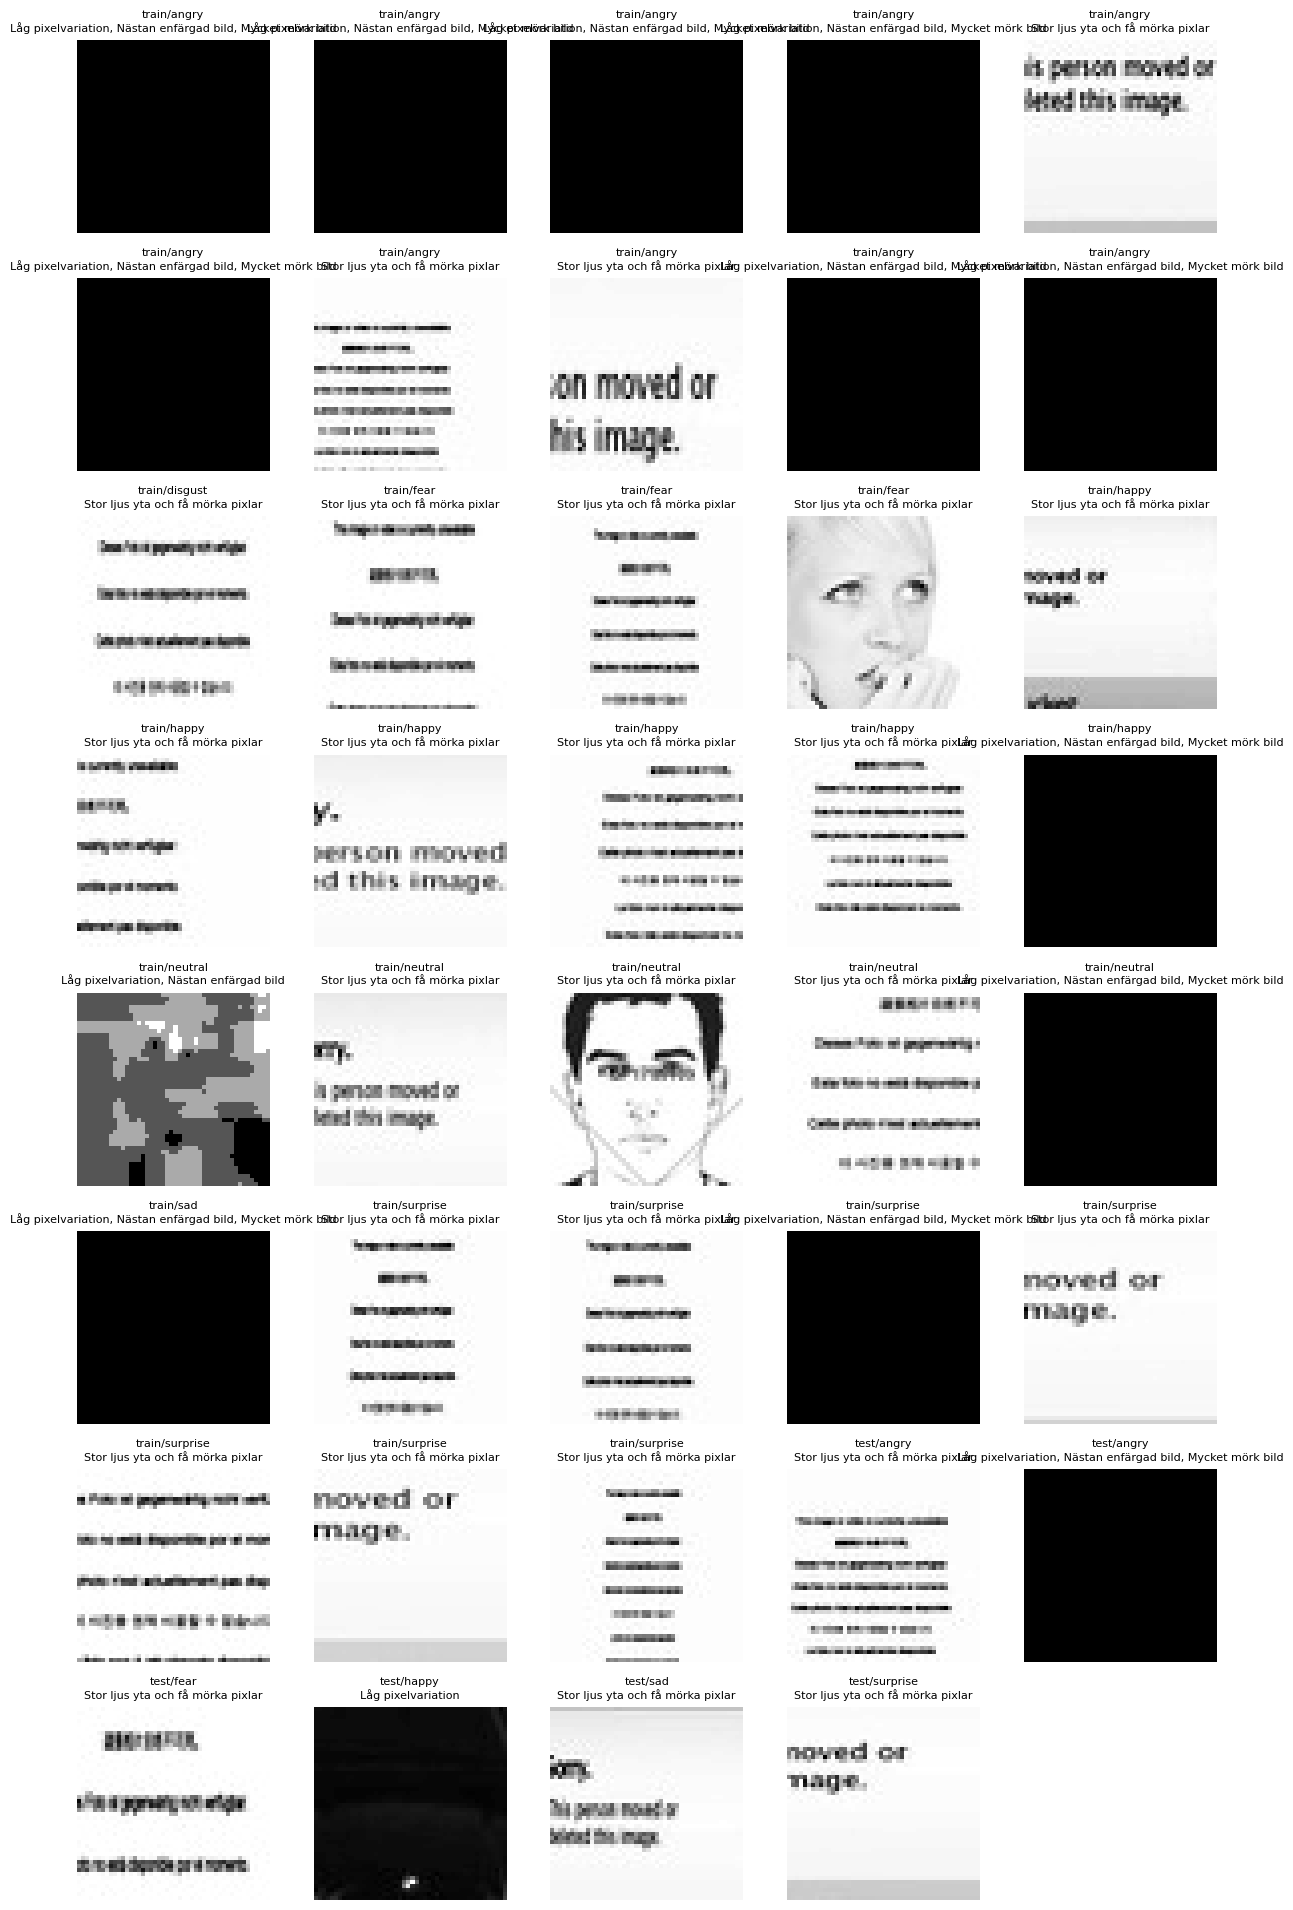

: 

In [ ]:
from PIL import Image

TRAIN_DIR = Path("train")
TEST_DIR = Path("test")

def scan_suspicious_images(
    base_dir,
    std_threshold=5,
    mean_low=5,
    mean_high=250,
    white_ratio_threshold=0.75,
    dark_ratio_threshold=0.03
):
    """
    Söker efter tekniskt misstänkta bilder.
    Metoden är försiktig så att vanliga ljusa ansikten inte flaggas för ofta.
    """

    suspicious = []

    image_paths = (
        list(base_dir.rglob("*.jpg")) +
        list(base_dir.rglob("*.jpeg")) +
        list(base_dir.rglob("*.png"))
    )

    for path in image_paths:
        try:
            img = Image.open(path).convert("L")
            arr = np.array(img)

            mean_value = arr.mean()
            std_value = arr.std()
            min_value = arr.min()
            max_value = arr.max()

            white_ratio = np.mean(arr > 220)
            dark_ratio = np.mean(arr < 60)
            value_range = max_value - min_value

            reason = []

            # Nästan tomma/enfärgade bilder
            if std_value < std_threshold:
                reason.append("Låg pixelvariation")

            if value_range < 10:
                reason.append("Nästan enfärgad bild")

            # Extremt mörka bilder
            if mean_value < mean_low:
                reason.append("Mycket mörk bild")

            # Extremt ljusa bilder med låg variation
            # Detta minskar risken att vanliga ljusa ansikten flaggas.
            if mean_value > mean_high and std_value < 20:
                reason.append("Mycket ljus bild med låg variation")

            # Bilder som mest består av ljus bakgrund/text,
            # men nästan saknar mörka ansiktsdrag.
            if white_ratio > white_ratio_threshold and dark_ratio < dark_ratio_threshold:
                reason.append("Stor ljus yta och få mörka pixlar")

            if reason:
                suspicious.append({
                    "path": str(path),
                    "dataset": base_dir.name,
                    "class_name": path.parent.name,
                    "mean": round(mean_value, 2),
                    "std": round(std_value, 2),
                    "min": int(min_value),
                    "max": int(max_value),
                    "white_ratio": round(white_ratio, 3),
                    "dark_ratio": round(dark_ratio, 3),
                    "reason": ", ".join(reason)
                })

        except Exception as e:
            suspicious.append({
                "path": str(path),
                "dataset": base_dir.name,
                "class_name": path.parent.name,
                "mean": None,
                "std": None,
                "min": None,
                "max": None,
                "white_ratio": None,
                "dark_ratio": None,
                "reason": f"Kunde inte läsa bilden: {e}"
            })

    return pd.DataFrame(suspicious)


def show_suspicious_images(df, n=20):
    if df.empty:
        print("Inga misstänkta bilder hittades.")
        return

    sample_df = df.head(n)

    cols = 5
    rows = int(np.ceil(len(sample_df) / cols))

    plt.figure(figsize=(12, rows * 2.4))

    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        img = Image.open(row["path"]).convert("L")

        plt.subplot(rows, cols, i)
        plt.imshow(img, cmap="gray")
        plt.title(
            f'{row["dataset"]}/{row["class_name"]}\n{row["reason"]}',
            fontsize=8
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


suspicious_train = scan_suspicious_images(TRAIN_DIR)
suspicious_test = scan_suspicious_images(TEST_DIR)

suspicious_images = pd.concat(
    [suspicious_train, suspicious_test],
    ignore_index=True
)

print("Antal misstänkta bilder:", len(suspicious_images))

display(suspicious_images.head(40))

show_suspicious_images(suspicious_images, n=39)

## Slutsats

> Då det var väldigt fåtal bilder jämfört med hur stort data-settet är så borde inte det påverka modellen något nämnvärt.